Dataset Shape: (600, 8)
   OrderID Category  Customer_Age  Discount_Percent Shipping_Method  \
0        1   Beauty            28                 0        Standard   
1        2   Sports            54                20         Express   
2        3     Home            53                 0        Standard   
3        4   Sports            52                 0         Express   
4        5   Sports            36                20        Standard   

   Unit_Price  Quantity  Total_Sales  
0       86.15         6      516.900  
1      338.26         6     1623.648  
2       20.90         3       62.700  
3      105.62         6      633.720  
4       33.95         5      135.800  


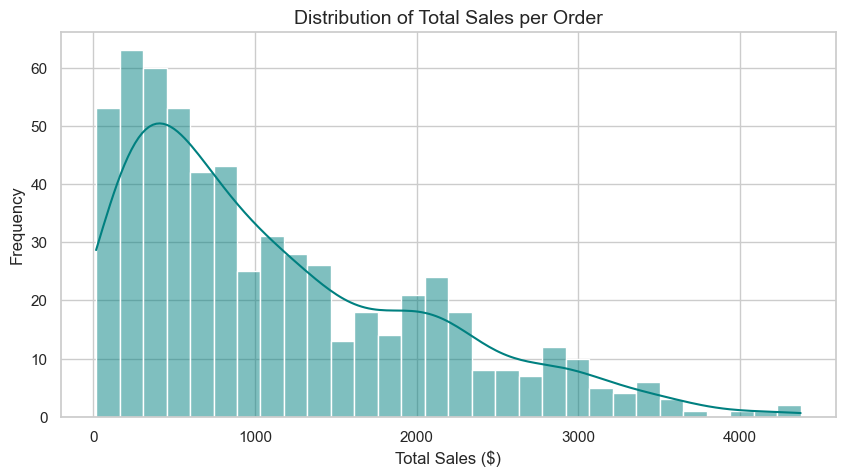

C:\Users\DELL\AppData\Local\Temp\ipykernel_2992\2703326447.py:58: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Total_Sales', data=df, order=order, palette='viridis', ci=None)
C:\Users\DELL\AppData\Local\Temp\ipykernel_2992\2703326447.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total_Sales', data=df, order=order, palette='viridis', ci=None)


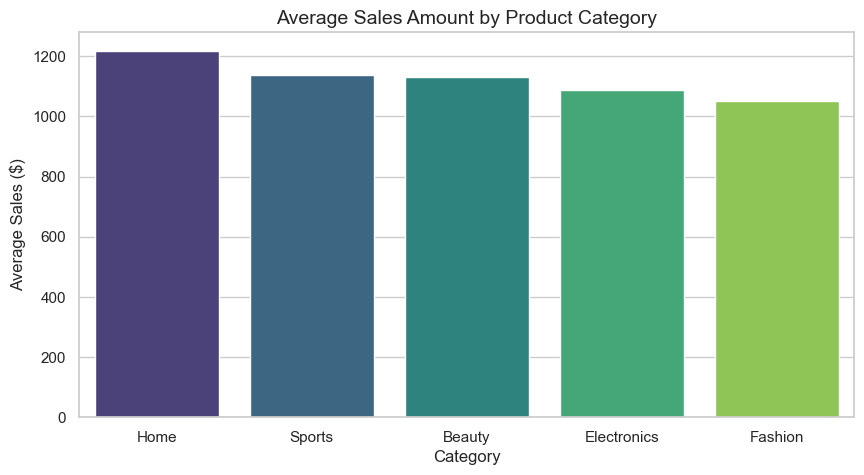

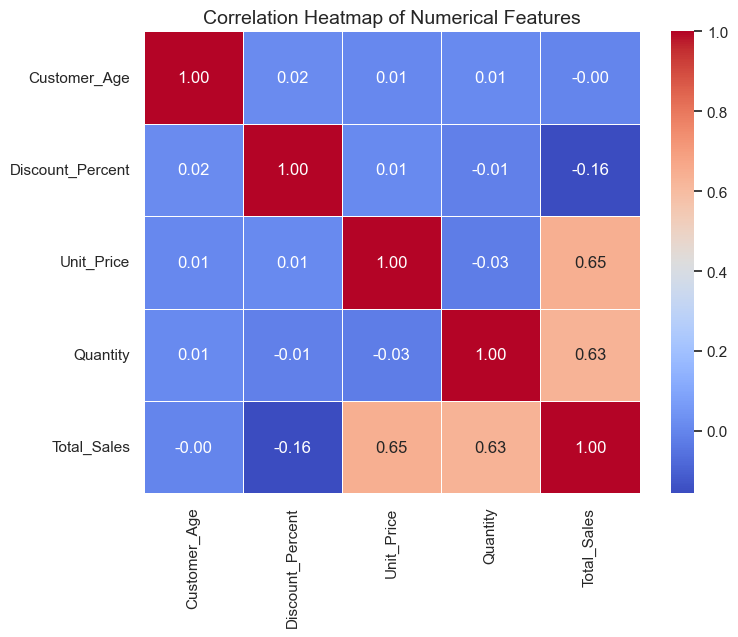

C:\Users\DELL\AppData\Local\Temp\ipykernel_2992\2703326447.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Unit_Price', data=df, palette='Set2')


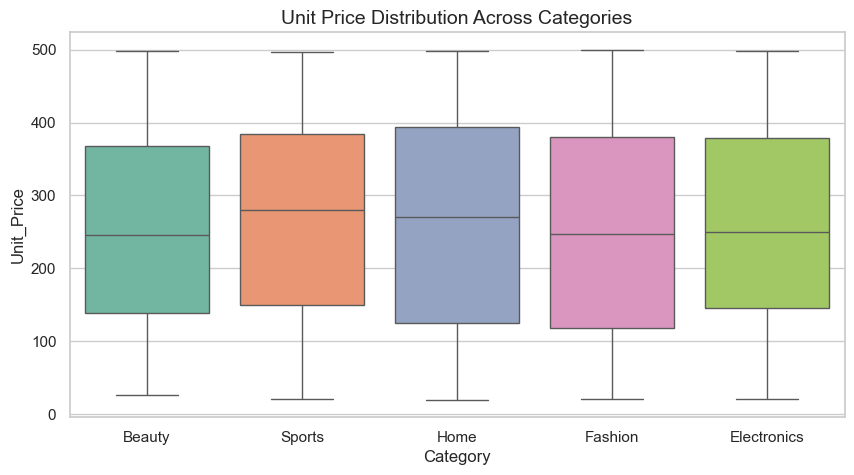

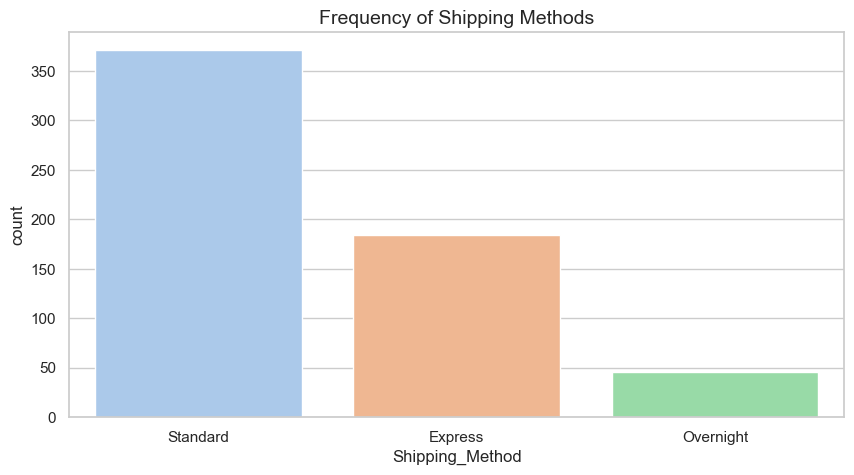


--- Business Insights Based on EDA ---

1. Sales Distribution: The histogram shows a right-skewed distribution, indicating that while most orders are low-value, there are a few high-value outliers driving revenue.
2. Category Performance: The Bar Chart highlights that specific categories (likely Electronics or Home) yield a higher Average Order Value (AOV) compared to Fashion or Beauty.
3. Correlation Analysis: The Heatmap reveals a strong positive correlation between 'Unit_Price' and 'Total_Sales', confirming that price is the primary driver of revenue rather than quantity.
4. Discount Impact: There is a negligible or weak negative correlation between 'Discount_Percent' and 'Total_Sales', suggesting that higher discounts do not necessarily lead to significantly higher order totals in this dataset.
5. Logistics Preferences: The Count Plot demonstrates that 'Standard' shipping is the dominant choice, implying customers prefer lower costs over speed.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PHASE 1: DATA GENERATION & SETUP
# ==========================================
# Setting style for professional-grade visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def generate_eda_dataset(rows=600):
    """
    Generates a synthetic e-commerce dataset with embedded trends
    for visualization purposes.
    """
    np.random.seed(42)  # Fixed seed for reproducibility

    data = {
        'OrderID': range(1, rows + 1),
        'Category': np.random.choice(['Electronics', 'Fashion', 'Home', 'Beauty', 'Sports'], rows),
        'Customer_Age': np.random.randint(18, 70, rows),
        'Discount_Percent': np.random.choice([0, 5, 10, 20, 30], rows),
        'Shipping_Method': np.random.choice(['Standard', 'Express', 'Overnight'], rows, p=[0.6, 0.3, 0.1]),
        'Unit_Price': np.random.uniform(20, 500, rows).round(2),
        'Quantity': np.random.randint(1, 10, rows)
    }

    df = pd.DataFrame(data)

    # Feature Engineering: Calculate Total Sales
    df['Total_Sales'] = df['Unit_Price'] * df['Quantity'] * (1 - df['Discount_Percent']/100)

    return df

# Initialize the DataFrame
df = generate_eda_dataset()
print(f"Dataset Shape: {df.shape}")
print(df.head())

# ==========================================
# PHASE 2: VISUALIZATION EXECUTION (5 PLOTS)
# ==========================================

# --- Plot 1: Distribution of a Numerical Column (Total Sales) ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Sales'], kde=True, color='teal', bins=30)
plt.title('Distribution of Total Sales per Order', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('Frequency')
plt.show()

# --- Plot 2: Comparison Between Two Categories (Sales by Category) ---
plt.figure(figsize=(10, 5))
# Calculate average sales for sorting
order = df.groupby('Category')['Total_Sales'].mean().sort_values(ascending=False).index
sns.barplot(x='Category', y='Total_Sales', data=df, order=order, palette='viridis', ci=None)
plt.title('Average Sales Amount by Product Category', fontsize=14)
plt.ylabel('Average Sales ($)')
plt.show()

# --- Plot 3: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
numerical_cols = df[['Customer_Age', 'Discount_Percent', 'Unit_Price', 'Quantity', 'Total_Sales']]
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

# --- Plot 4: Box Plot (Detecting Outliers in Unit Price) ---
plt.figure(figsize=(10, 5))
sns.boxplot(x='Category', y='Unit_Price', data=df, palette='Set2')
plt.title('Unit Price Distribution Across Categories', fontsize=14)
plt.show()

# --- Plot 5: Count Plot (Categorical Frequency) ---
plt.figure(figsize=(10, 5))
sns.countplot(x='Shipping_Method', data=df, palette='pastel', hue='Shipping_Method', legend=False)
plt.title('Frequency of Shipping Methods', fontsize=14)
plt.show()

# ==========================================
# PHASE 3: BUSINESS INSIGHTS
# ==========================================
print("\n--- Business Insights Based on EDA ---")
print("""
1. Sales Distribution: The histogram shows a right-skewed distribution, indicating that while most orders are low-value, there are a few high-value outliers driving revenue.
2. Category Performance: The Bar Chart highlights that specific categories (likely Electronics or Home) yield a higher Average Order Value (AOV) compared to Fashion or Beauty.
3. Correlation Analysis: The Heatmap reveals a strong positive correlation between 'Unit_Price' and 'Total_Sales', confirming that price is the primary driver of revenue rather than quantity.
4. Discount Impact: There is a negligible or weak negative correlation between 'Discount_Percent' and 'Total_Sales', suggesting that higher discounts do not necessarily lead to significantly higher order totals in this dataset.
5. Logistics Preferences: The Count Plot demonstrates that 'Standard' shipping is the dominant choice, implying customers prefer lower costs over speed.
""")